# Project Name : Supermarket Profitability Prediction

In [308]:
# import pandas 
import pandas as pd

In [309]:
# Import the CSV

df = pd.read_csv("Sample - Superstore.csv")

In [310]:
# Viewing the data
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,8/11/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,8/11/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,12/6/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,11/10/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,11/10/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [311]:
# Size of data
df.shape

(9994, 21)

In [312]:
# Columns 
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [313]:
df.info()

data_info = {
"Total columns" : 21,
"Totat entries" : 9994,
"Dtypes" : "float64(3), int64(2), str(16)",
      }

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   object 
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

This is what we got from the dataset:

- **Total columns:** 21
- **Total entries:** 9994
- **Dtypes:** `float64(3), int64(2), str(16)`

In [314]:
# check for null values
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

No null values are present in dataset

In [315]:
# Check for Duplicate values
df.duplicated().sum()

np.int64(0)

In [316]:
# get the loc of columns
df.columns.get_loc('Sales')

17

In [317]:
# describe the data
df.loc[:,['Sales','Profit']].describe()

,Sales,Profit
count,9994.000000,9994.000000
mean,229.858001,28.656896
std,623.245101,234.260108
min,0.444000,-6599.978000
25%,17.280000,1.728750
50%,54.490000,8.666500
75%,209.940000,29.364000
max,22638.480000,8399.976000


- No missing values are observed in the numerical columns since the count is equal to the total number of records.
- Sales and Profit appear to be right-skewed because their means are higher than their medians.
- The large gap between the maximum values and the third quartiles suggests the presence of outliers.
- The high standard deviations indicate substantial variability in Sales and Profit.

In [318]:
import matplotlib.pyplot as plt

In [319]:
import seaborn as sns

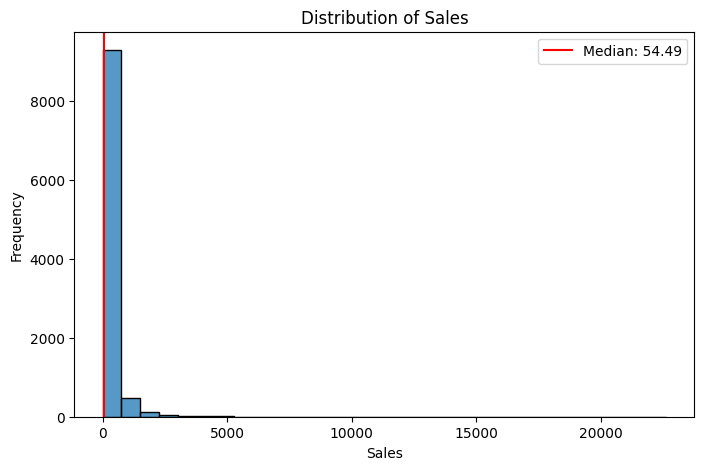

In [320]:
# Distribution of sales 

plt.figure(figsize = [8,5])
sns.histplot(df['Sales'], bins = 30)

# median 
median = df['Sales'].median()

# plotting the vertical median line on hist
plt.axvline(
    x=median,
    color = "Red",
    linestyle = "-",
    label=f'Median: {median:.2f}'
)

plt.legend()
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

### Conclusion

- The Sales distribution is positively (right) skewed.
- Most transactions have low sales values.
- A few transactions have exceptionally high sales values.
- The mean is greater than the median, confirming the right skewness.
- The data does not follow a normal distribution.

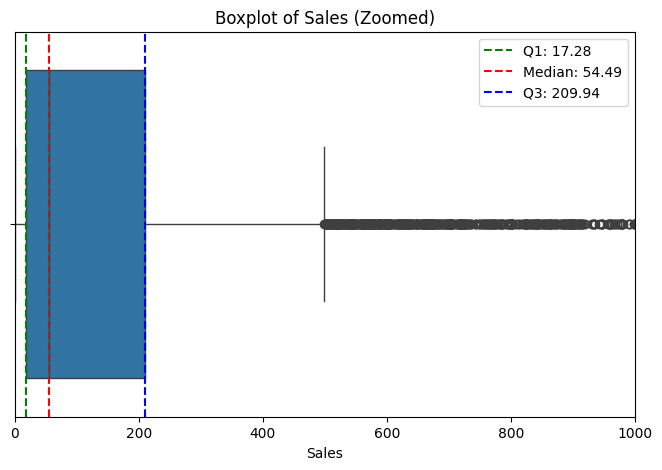

In [321]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['Sales'])

stats = {
    'Q1': df['Sales'].quantile(0.25),
    'Median': df['Sales'].median(),
    'Q3': df['Sales'].quantile(0.75)
}

colors = {
    'Q1': 'green',
    'Median': 'red',
    'Q3': 'blue'
}

for label, value in stats.items():
    plt.axvline(
        x=value,
        color=colors[label],
        linestyle='--',
        label=f'{label}: {value:.2f}'
    )


plt.legend()
plt.xlim(0, 1000)   # Zoom in
plt.title('Boxplot of Sales (Zoomed)')
plt.show()

### Observations

- The Sales distribution is highly positively skewed.
- Most transactions involve relatively low sales values.
- Several high-value transactions are present as outliers.
- The middle 50% of Sales values lie within a relatively narrow range.
- A few large orders significantly influence the distribution.

In [322]:
# categorical analysis

category_analysis = { 
'Category' : df['Category'].value_counts(),
'Sub_Category':df['Sub-Category'].value_counts(),
'Region':df['Region'].value_counts(),
'Segment':df['Segment'].value_counts()
}

for cate, value in category_analysis.items():
    print(f"{cate}:{value}\n")
    print('*' * 50)

Category:Category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64

**************************************************
Sub_Category:Sub-Category
Binders        1523
Paper          1370
Furnishings     957
Phones          889
Storage         846
Art             796
Accessories     775
Chairs          617
Appliances      466
Labels          364
Tables          319
Envelopes       254
Bookcases       228
Fasteners       217
Supplies        190
Machines        115
Copiers          68
Name: count, dtype: int64

**************************************************
Region:Region
West       3203
East       2848
Central    2323
South      1620
Name: count, dtype: int64

**************************************************
Segment:Segment
Consumer       5191
Corporate      3020
Home Office    1783
Name: count, dtype: int64

**************************************************


In [323]:
# Which states contribute the most sales?

state_sales = df.groupby('State')['Sales'].sum()

state_sales.sort_values(ascending=False).head(10)

State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Florida          89473.7080
Illinois         80166.1010
Ohio             78258.1360
Michigan         76269.6140
Virginia         70636.7200
Name: Sales, dtype: float64

### Conclusion

- The West region contributes the highest Sales and Profit.
- The South region records comparatively lower Sales and Profit.
- Regional performance varies significantly across the business.

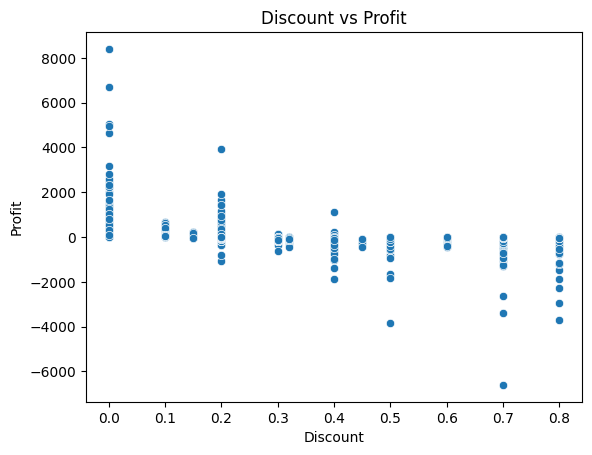

In [324]:
# Discount Impact Analysis

sns.scatterplot(
    data=df,
    x='Discount',
    y='Profit'
)

plt.title('Discount vs Profit')
plt.show()

### Conclusion

- Higher discounts generally lead to lower profits.
- Several transactions with high discounts result in losses.
- Excessive discounting adversely affects profitability.

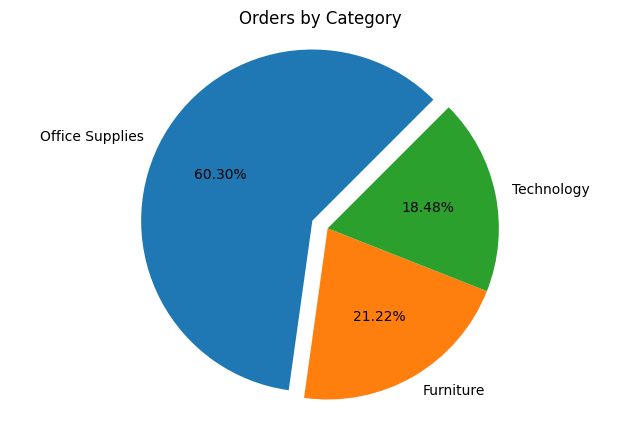

In [325]:
# Which category has the least orders?

plt.figure(figsize=[8,5])

category_counts = df["Category"].value_counts()

plt.pie(
    category_counts.values,
    labels=category_counts.index,
    autopct='%1.2f%%',
    startangle=45,      # Rotate chart
    explode=[0.1, 0, 0],  # Highlight first slice
)

plt.title("Orders by Category")
plt.axis('equal')  

plt.show()

### Conclusion

- The category with the highest number of orders is Office Supplies.
- The category with the lowest number of orders is Technology.
- Most customers prefer products from the Office Supplies category.

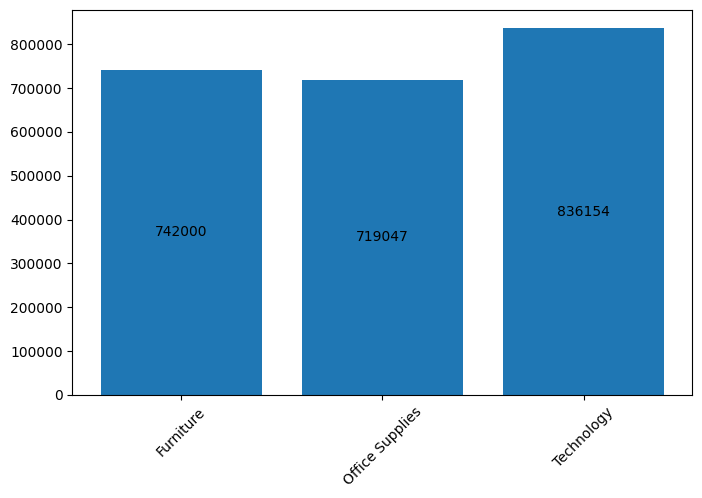

In [326]:
# Which category generates the highest sales?

category_sales = df.groupby("Category")['Sales'].sum()

plt.figure(figsize=[8,5])

bar = plt.bar(category_sales.index,category_sales.values)
plt.bar_label(bar, label_type='center')
plt.xticks(rotation=45)

plt.show()

### Conclsuion 

- Highest sales in category is of Technology.
- Furniture and Office Supplies are quite similar.
- Lowest category for now is Office Supplies by **719047** sales.

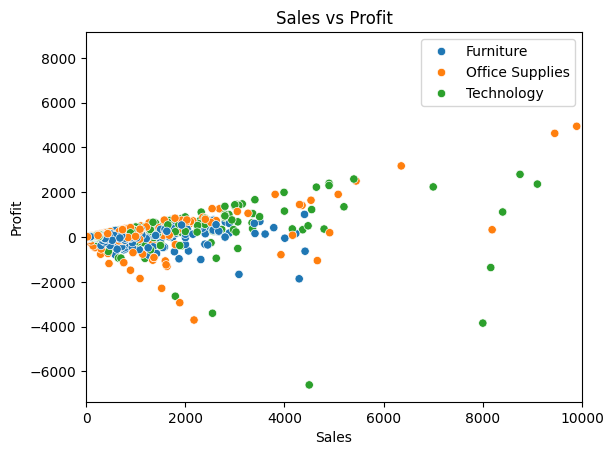

In [327]:
# Does higher Sales lead to higher Profit?

sns.scatterplot(
    data=df,
    x='Sales',
    y='Profit',
    hue='Category'
)

plt.legend()
plt.title('Sales vs Profit')
plt.xlim(0,10000)
plt.show()

### Conclusion

- There is a positive correlation between **Sales** and **Profit**.
- Higher sales generally lead to higher profits.
- Some high-sales transactions generate losses, indicating that other factors affect profitability.

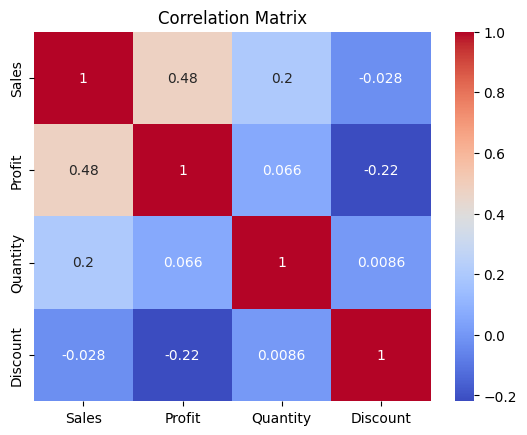

In [328]:
# Which variables are strongly related?

corr = df[['Sales', 'Profit', 'Quantity', 'Discount']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

### Conclusion 

- Sales and Profit show a moderate positive correlation, indicating that higher sales generally lead to higher profits.
- Discount and Profit exhibit a negative correlation, suggesting that larger discounts reduce profitability.
- Quantity has a weak correlation with Profit, indicating that quantity sold alone does not strongly impact profit.

# Final Conclusion

- The dataset contains no significant data quality issues after cleaning.
- Sales and Profit distributions are highly right-skewed with several outliers.
- Technology category generates the highest profit.
- Some sub-categories such as Tables and Bookcases incur losses.
- The West region contributes the highest sales and profit.
- Higher Sales do not always guarantee higher Profit.
- Excessive discounts negatively impact profitability.
- A small number of high-value orders contribute significantly to overall sales.

# Feature Engineering

In [329]:
# Create a Profitability Flag

df['Is_Profitable'] = df['Profit'].apply(
    lambda x: 1 if x > 0 else 0
)

df[['Profit', 'Is_Profitable']].head()

,Profit,Is_Profitable
0,41.9136,1
1,219.5820,1
2,6.8714,1
3,-383.0310,0
4,2.5164,1


In [330]:
# Extract Date Features

df['Order Date'] = pd.to_datetime(df['Order Date'])


In [331]:
# Year

df['Year'] = df['Order Date'].dt.year
df['Year']

0       2016
1       2016
2       2016
3       2015
4       2015
        ... 
9989    2014
9990    2017
9991    2017
9992    2017
9993    2017
Name: Year, Length: 9994, dtype: int32

In [332]:
# Month
df['Month'] = df['Order Date'].dt.month
df['Month']

0        8
1        8
2       12
3       11
4       11
        ..
9989     1
9990     2
9991     2
9992     2
9993     4
Name: Month, Length: 9994, dtype: int32

In [333]:
df['Quarter'] = df['Order Date'].dt.quarter

In [334]:
df['DayofWeek'] = df['Order Date'].dt.day_name()

In [335]:
# Profit Margin

df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100
df['Profit Margin'] = df['Profit Margin'].map('{:.2f}'.format)

In [336]:
# Discount Category

def discount_category(discount):
    if discount == 0:
        return 'No discount'
    elif discount <= 0.2:
        return 'Low'
    elif discount <= 0.5:
        return 'Medium'
    else:
        return 'High'

df['discount_level'] = df['Discount'].apply(discount_category)

In [337]:
# Average Selling Price per Quantity

def Average_Selling_Price_per_Quantity(row):
    return row['Sales'] / row['Quantity']
    
df['Avg_Selling_per_Quantity'] = df.apply(
    Average_Selling_Price_per_Quantity,
    axis=1
).map('{:.2f}'.format)

# Data Preprocessing

In [338]:
# Encode Categorical Variables

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Category_Encoded'] = le.fit_transform(df['Category'])

In [339]:
df = pd.get_dummies(
    df,
    columns=['Category', 'Region'],
    drop_first=True
)

In [340]:
# Remove Unnecessary Columns

drop_cols = [
    'Row ID',
    'Order ID',
    'Customer ID',
    'Customer Name',
    'Country',
    'Order Date',
    'Postal Code',
    'Product Name',
    'Ship Date',
    'Product ID'
]

df.drop(drop_cols, axis=1, inplace=True)

In [341]:
df.select_dtypes(include='object').columns

Index(['Ship Mode', 'Segment', 'City', 'State', 'Sub-Category', 'DayofWeek',
       'Profit Margin', 'discount_level', 'Avg_Selling_per_Quantity'],
      dtype='object')

In [342]:
df['Avg_Selling_per_Quantity'] = df['Avg_Selling_per_Quantity'].astype(float)

In [343]:
df['Profit Margin'] = df['Profit Margin'].astype(float)

In [344]:
categorical_cols = df.select_dtypes(include='object').columns

df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

In [345]:
# Features (independent variables)
X = df.drop(['Is_Profitable', 'Profit','Profit Margin'], axis=1)

# Target variable (dependent variable)
y = df['Is_Profitable']

In [346]:
# Split the data

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [347]:
# Train a Model

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [348]:
# prediction

y_pred = model.predict(X_test)

In [349]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9349674837418709
Precision: 0.9515738498789347
Recall: 0.969173859432799
F1 Score: 0.9602932193036041
[[ 297   80]
 [  50 1572]]


In [350]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9349674837418709


In [2]:
pip install streamlit


  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached protobuf-7.35.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached uvicorn-0.49.0-py3-none-any.whl.metadata (6.7 kB)
  Using cached itsdangerous-2.2.0-py3-none-any.whl.metadata (1.9 kB)
  Using cached narwhals-2.22.1-py3-none-any.whl.metadata (15 kB)
   ---------------------------------------- 0.0/9.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.2 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.2 MB 3.0 MB/s eta 0:00:03
   --------- ------------------------------ 2.1/9.2 MB 3.6 MB/s eta 0:00:03
   ------------- -------------------------- 3.1/9.2 MB 4.0 MB/s eta 0:00:02
   -------------------- ------------------- 4.7/9.2 MB 4.7 MB/s eta 0:00:01
   ----------------------------- ---------- 6.8/9.2 MB 5.6 MB/s eta 0:00:01
   ---------------------------------------  9.2/9.2 MB 6.6 MB/s eta 0:00:01
   ---------------------------------------- 9.2/9.2 MB 6.3 MB/s  